# Importing the data
Here I am importing the dataset by calling the API of the Web App created in the first assignment So that data integrity is 
there for both the assignments using the same logic used in the Web App. Also I want to get the data of all the horizons from 0 
to 48 so that I can determine how the accuracy changes with ranging horizons. if I had to bet I would bet that accuracy will 
decrease with increasing horizon I think so.

In [6]:
import requests
import pandas as pd
import time
from datetime import datetime, timezone
start_date_str = "2024-01-01"
end_date_str="2024-01-31"
sdt = datetime.strptime(start_date_str, "%Y-%m-%d")
edt = datetime.strptime(end_date_str, "%Y-%m-%d")
start_utc_date = sdt.replace(tzinfo=timezone.utc).isoformat()
end_utc_date=edt.replace(tzinfo=timezone.utc).isoformat()
url = "https://forecast-web-app-n2nu.vercel.app/api"

all_data = []

for horizon in range(0,49):

    payload = {
        "startDate": start_utc_date,
        "endDate": end_utc_date,
        "horizon": horizon
    }

    response = requests.post(url, json=payload)

    data = response.json()

    for row in data:
        row["horizon"] = horizon   # add horizon column

    all_data.extend(data)
    time.sleep(1)


df = pd.DataFrame(all_data)

df.head()

,startTime,actualGen,foreCastGen,horizon
0,2024-01-01T21:00:00Z,13953,11730,0
1,2024-01-01T22:00:00Z,14217,13120,0
2,2024-01-01T23:00:00Z,14958,14426,0
3,2024-01-02T00:00:00Z,14690,15364,0
4,2024-01-02T01:00:00Z,14592,15807,0


In [8]:
df.tail()

,startTime,actualGen,foreCastGen,horizon
33367,2024-01-30T17:00:00Z,7193,8489,48
33368,2024-01-30T18:00:00Z,6626,8388,48
33369,2024-01-30T19:00:00Z,6415,7726,48
33370,2024-01-30T20:00:00Z,6622,8089,48
33371,2024-01-30T21:00:00Z,7217,8465,48


# Adding error,absolute error and error percentage while cleaning the data 
Adding columns
1. error which is actualGen-foreCastGen
2. absError which is absolute value of error
3. errorPct which is error Percentage


In [9]:
df['error']=df['actualGen']-df['foreCastGen']

In [12]:
df['absError']=abs(df['error'])

In [13]:
df.head()

,startTime,actualGen,foreCastGen,horizon,error,absError
0,2024-01-01T21:00:00Z,13953,11730,0,2223,2223
1,2024-01-01T22:00:00Z,14217,13120,0,1097,1097
2,2024-01-01T23:00:00Z,14958,14426,0,532,532
3,2024-01-02T00:00:00Z,14690,15364,0,-674,674
4,2024-01-02T01:00:00Z,14592,15807,0,-1215,1215


In [16]:
df['errorPct']=((df['absError']/df['actualGen'])*100).round(2)

In [17]:
df.head()

,startTime,actualGen,foreCastGen,horizon,error,absError,errorPct
0,2024-01-01T21:00:00Z,13953,11730,0,2223,2223,15.93
1,2024-01-01T22:00:00Z,14217,13120,0,1097,1097,7.72
2,2024-01-01T23:00:00Z,14958,14426,0,532,532,3.56
3,2024-01-02T00:00:00Z,14690,15364,0,-674,674,4.59
4,2024-01-02T01:00:00Z,14592,15807,0,-1215,1215,8.33


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33372 entries, 0 to 33371
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   startTime    33372 non-null  object 
 1   actualGen    33372 non-null  int64  
 2   foreCastGen  33372 non-null  int64  
 3   horizon      33372 non-null  int64  
 4   error        33372 non-null  int64  
 5   absError     33372 non-null  int64  
 6   errorPct     33372 non-null  float64
dtypes: float64(1), int64(5), object(1)
memory usage: 1.8+ MB


# Converting startTime to date object

In [19]:
df["startTime"] = pd.to_datetime(df["startTime"])

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33372 entries, 0 to 33371
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   startTime    33372 non-null  datetime64[ns, UTC]
 1   actualGen    33372 non-null  int64              
 2   foreCastGen  33372 non-null  int64              
 3   horizon      33372 non-null  int64              
 4   error        33372 non-null  int64              
 5   absError     33372 non-null  int64              
 6   errorPct     33372 non-null  float64            
dtypes: datetime64[ns, UTC](1), float64(1), int64(5)
memory usage: 1.8 MB


In [21]:
df.head()

,startTime,actualGen,foreCastGen,horizon,error,absError,errorPct
0,2024-01-01 21:00:00+00:00,13953,11730,0,2223,2223,15.93
1,2024-01-01 22:00:00+00:00,14217,13120,0,1097,1097,7.72
2,2024-01-01 23:00:00+00:00,14958,14426,0,532,532,3.56
3,2024-01-02 00:00:00+00:00,14690,15364,0,-674,674,4.59
4,2024-01-02 01:00:00+00:00,14592,15807,0,-1215,1215,8.33


In [22]:
df.describe()

,actualGen,foreCastGen,horizon,error,absError,errorPct
count,33372.000000,33372.000000,33372.000000,33372.000000,33372.000000,33372.0000
mean,9683.331985,11000.278467,23.519208,-1316.946482,2024.088397,inf
std,3687.928233,4928.577631,13.966885,2259.778642,1656.485107,NaN
min,0.000000,2708.000000,0.000000,-18077.000000,0.000000,0.0000
25%,6484.000000,6762.000000,11.000000,-2863.000000,698.000000,9.0775
50%,9487.000000,9539.500000,23.000000,-1213.000000,1716.000000,18.2300
75%,12901.000000,15777.000000,36.000000,195.000000,2994.000000,27.6300
max,16434.000000,19818.000000,48.000000,4788.000000,18077.000000,inf


Here This shows on an average the model is off by around 2024 MW. 

# How forecast accuracy changes with horizon changing
This is the reason why we want the data for 0-48 horizons so that we can see with changing horizon, how forecast errors change

In [25]:
horizonError=df.groupby("horizon")["absError"].mean().round(2)

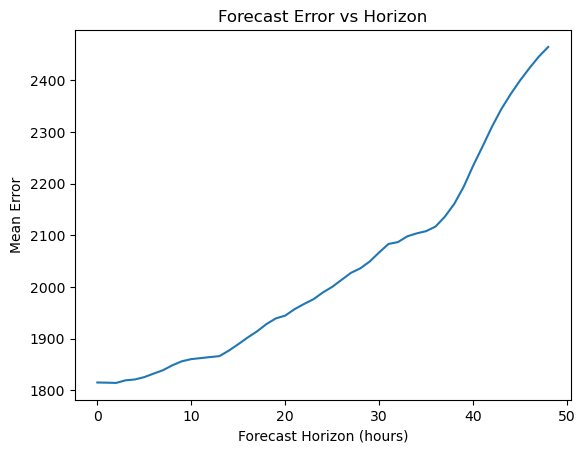

In [28]:
import matplotlib.pyplot as plt

plt.plot(horizonError.index, horizonError.values)
plt.xlabel("Forecast Horizon (hours)")
plt.ylabel("Mean Error")
plt.title("Forecast Error vs Horizon")
plt.show()

This graph shows that we are more prone to errors when we increase the forecast horizon hours.

<AxesSubplot:>

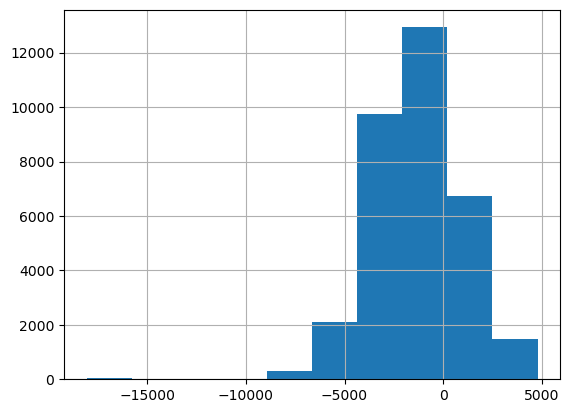

In [30]:
df["error"].hist()

In [34]:
df["hour"] = pd.to_datetime(df["startTime"]).dt.hour
errorsByHours=df.groupby("hour")["absError"].mean()

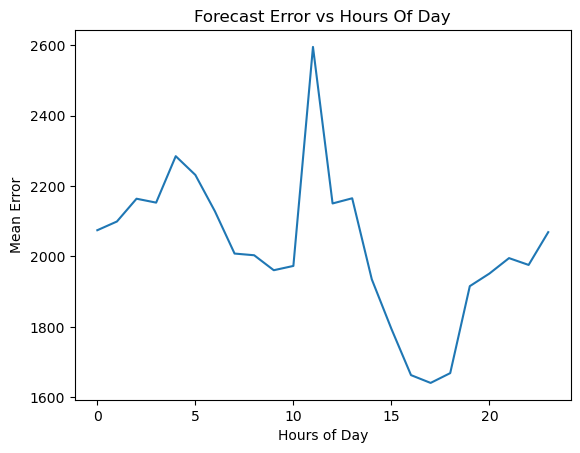

In [35]:
plt.plot(errorsByHours.index, errorsByHours.values)
plt.xlabel("Hours of Day")
plt.ylabel("Mean Error")
plt.title("Forecast Error vs Hours Of Day")
plt.show()

This graph shows That there is a spike in errors especially in the hours between 10 AM and 1 PM and after that it takes a sharp
dip.

In [42]:
medianErrorByHorizon=df.groupby('horizon')['absError'].median().round(2)

In [43]:
p99ErrorByHorizon=df.groupby('horizon')['absError'].quantile(0.99).round(2)

In [44]:
print(medianErrorByHorizon)

horizon
0     1423.0
1     1423.0
2     1423.0
3     1435.0
4     1443.0
5     1452.0
6     1452.0
7     1433.0
8     1422.0
9     1423.0
10    1419.0
11    1419.0
12    1425.0
13    1410.0
14    1437.0
15    1499.0
16    1523.0
17    1528.0
18    1578.0
19    1594.0
20    1627.0
21    1636.0
22    1639.0
23    1649.0
24    1656.0
25    1692.5
26    1693.0
27    1708.0
28    1734.0
29    1739.0
30    1795.0
31    1833.0
32    1884.0
33    1928.5
34    1945.0
35    1974.5
36    2005.0
37    2038.5
38    2109.0
39    2136.0
40    2164.0
41    2200.5
42    2244.0
43    2253.5
44    2299.0
45    2324.0
46    2345.5
47    2402.0
48    2404.0
Name: absError, dtype: float64


In [45]:
print(p99ErrorByHorizon)

horizon
0     6309.94
1     6309.94
2     6309.94
3     6309.94
4     6249.18
5     6249.18
6     6364.20
7     6364.20
8     6364.20
9     6364.20
10    6775.28
11    6775.28
12    6775.28
13    6775.28
14    6411.72
15    6636.14
16    6636.14
17    6636.14
18    6639.14
19    6646.74
20    6715.76
21    6787.25
22    6794.30
23    6801.35
24    6808.48
25    6815.54
26    6829.10
27    7085.12
28    7083.20
29    7427.72
30    7428.16
31    7428.60
32    7154.52
33    7158.24
34    7146.30
35    7069.08
36    6770.20
37    6773.86
38    6417.76
39    6639.13
40    6772.40
41    6898.50
42    6898.68
43    6898.86
44    6833.24
45    6872.85
46    6714.57
47    6601.44
48    6516.16
Name: absError, dtype: float64


Here We have calculated the p99 Error for different horizons which shows that 99% of the errors are below their respective p99value

In [49]:
bias=round(df["error"].mean(),2)
print("bias:",bias)

bias: -1316.95


A negative bias means that forecast generally over predicts the winds

# Wind generation Analysis

In [51]:
df["actualGen"].quantile([0.1,0.25,0.5,0.75,0.9])

0.10     4916.0
0.25     6484.0
0.50     9487.0
0.75    12901.0
0.90    14722.0
Name: actualGen, dtype: float64

This shows that
10% of the time wind generation is below 4916 MW
25% of the time wind generation is below 6485 MW
50% of the time wind generation is below 9487 MW
75% of the time wind generation is below 12901 MW
90% of the time wind generation is below 14722 MW

In [58]:
actualGenMean=round(df["actualGen"].mean(),2)
print("Mean of Actual Generation:",actualGenMean)

Mean of Actual Generation: 9683.33


In [59]:
import seaborn as sns

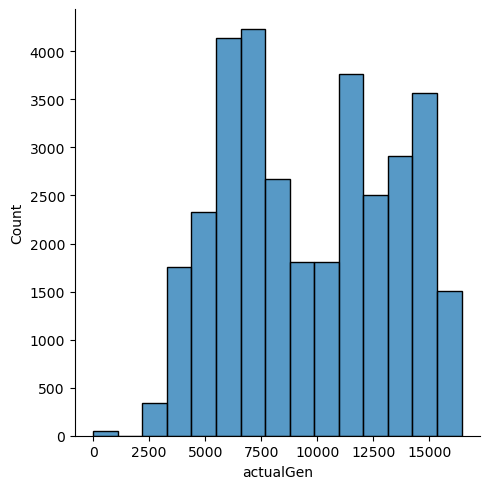

In [66]:
sns.displot(data=df,x="actualGen",bins=15)

This graph shows the count of different generations, from this we can say that most of the times wind generates somewhere around 
4000MW to 8000MW 

<AxesSubplot:xlabel='actualGen', ylabel='Density'>

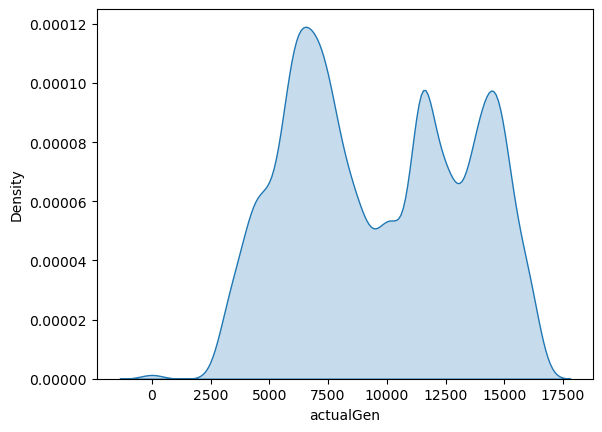

In [67]:
sns.kdeplot(data=df,x="actualGen",shade=True)

this kde plot shows where the generation is concentrated from the graph we can see that the generation is concentrated around 
4000MW to 8000MW then it dips and then we see two spikes around 11000MW and 15000MW

<AxesSubplot:xlabel='actualGen'>

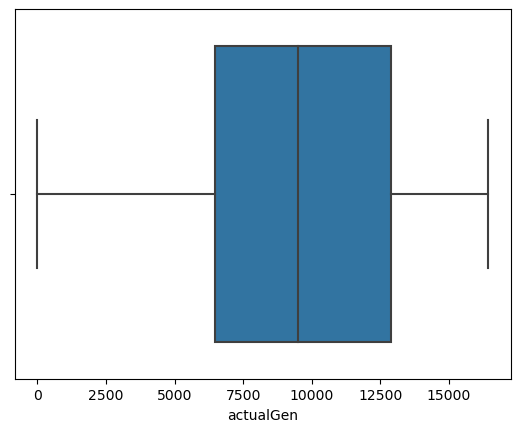

In [68]:
sns.boxplot(data=df,x="actualGen")

From this graph we can visualise in percentiles and anticipate that 50% of the data lies between 6000MW and 13000MW with
outliers being 0 and 16000MW

# Conclusion 
This analysis evaluated the accuracy and characteristics of wind power generation forecasts for January 2024. The observations from the analysis are as follows:

1. Forecast accuracy decreases as forecast horizon increases which was the intuition from the start forecasts with shorter horizons are more accurate.

2. There is a sharp rise in errors between 10AM and 1PM followed by a dip in errors from 3PM to 6PM we can say that the forecast is most accurate for 3PM to 6PM and highly inaccurate for 10AM to 1PM.

3. The bias is negative which means that the forecasts generally over predict the wind generation.

4. The p10 generation for the month of January is approximately around **4900MW** seeing this we can say that around 90% of the time wind generation is higher than this and we can consider this a reliable generation value to meet the electricity demand.

